In [89]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [90]:
stocks = [
    "ADANIENT.NS",
    "ADANIPORTS.NS",
    "APOLLOHOSP.NS",
    "ASIANPAINT.NS",
    "AXISBANK.NS",
    "BAJAJ-AUTO.NS",
    "BAJFINANCE.NS",
    "BEL.NS",
    "BHARTIARTL.NS",
    "CIPLA.NS",
    "COALINDIA.NS",
    "DRREDDY.NS",
    "EICHERMOT.NS",
    "ETERNAL.NS",   # formerly Zomato
    "GRASIM.NS",
    "HCLTECH.NS",
    "HDFCBANK.NS",
    "HDFCLIFE.NS",
    "HEROMOTOCO.NS",
    "HINDALCO.NS",
    "HINDUNILVR.NS",
    "ICICIBANK.NS",
    "INDUSINDBK.NS",
    "INFY.NS",
    "ITC.NS",
    "JIOFIN.NS",
    "JSWSTEEL.NS",
    "KOTAKBANK.NS",
    "LT.NS",
    "M&M.NS",
    "MARUTI.NS",
    "NESTLEIND.NS",
    "NTPC.NS",
    "ONGC.NS",
    "POWERGRID.NS",
    "RELIANCE.NS",
    "SBILIFE.NS",
    "SBIN.NS",
    "SHRIRAMFIN.NS",
    "SUNPHARMA.NS",
    "TATACONSUM.NS",
    "TATAMOTORS.NS",
    "TATASTEEL.NS",
    "TCS.NS",
    "TECHM.NS",
    "TITAN.NS",
    "TRENT.NS",
    "ULTRACEMCO.NS",
    "WIPRO.NS"
]




In [91]:
data = yf.download(
    stocks,
    start="2020-01-01",
   
    auto_adjust=True,
    progress=False
)["Close"]

data.head()

$TATAMOTORS.NS: possibly delisted; no timezone found

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,CIPLA.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATAMOTORS.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,205.794495,361.062592,1403.107056,1690.746582,745.586914,2599.727295,413.532166,29.713724,433.316498,449.420319,...,406.074036,306.714386,NaN,38.457085,1841.149658,602.617554,1132.704834,526.402649,3942.765625,113.709175
2020-01-02,209.111359,366.321014,1470.294312,1688.342529,753.802612,2575.711914,414.973724,30.603798,435.132690,447.153809,...,406.681732,306.240814,NaN,39.862999,1832.698242,605.740845,1133.538696,538.030884,4117.159180,113.984627
2020-01-03,206.240051,365.699585,1461.883545,1651.334717,739.860840,2535.314453,409.833038,29.951080,435.037109,443.801361,...,415.704559,301.363312,NaN,39.768444,1869.222046,612.897095,1117.942017,532.614380,4092.328125,115.269989
2020-01-06,197.576584,363.500580,1438.667847,1609.613037,720.242737,2506.924316,390.604340,28.764305,429.827362,440.779388,...,411.356812,295.586090,NaN,38.909279,1869.052246,609.180664,1136.481323,526.700867,4032.096191,115.751999
2020-01-07,202.032074,367.898529,1454.604004,1625.877319,722.732361,2507.171875,391.674500,28.586292,425.477997,442.526489,...,417.387573,298.237915,NaN,39.143593,1873.638916,614.478516,1137.805420,529.682434,4114.540527,117.152130


In [92]:
momentum = data.pct_change(252).shift(21)

rebalance_dates = momentum.index[252::21]


In [93]:
winner_returns = []
loser_returns = []

winner_history = {}
loser_history = {}

for i in range(len(rebalance_dates) - 1):

    current_date = rebalance_dates[i]
    next_date = rebalance_dates[i + 1]

    mom = momentum.loc[current_date].dropna()

    winners = mom.nlargest(5).index
    losers = mom.nsmallest(5).index

    winner_history[current_date] = winners
    loser_history[current_date] = losers

    current_loc = data.index.get_loc(current_date)

    if current_loc + 1 >= len(data):
        continue

    entry_date = data.index[current_loc + 1]

    winner_period = (
        data.loc[entry_date:next_date, winners]
        .pct_change()
        .mean(axis=1)
        .dropna()
    )

    loser_period = (
        data.loc[entry_date:next_date, losers]
        .pct_change()
        .mean(axis=1)
        .dropna()
    )

    winner_returns.append(winner_period)
    loser_returns.append(loser_period)

In [94]:
winner_returns = pd.concat(winner_returns)
loser_returns = pd.concat(loser_returns)

winner_returns = winner_returns[
    ~winner_returns.index.duplicated()
]

loser_returns = loser_returns[
    ~loser_returns.index.duplicated()
]



winner_curve = (1 + winner_returns).cumprod()

loser_curve = (1 + loser_returns).cumprod()

factor_returns = winner_returns - loser_returns

factor_curve = (1 + factor_returns).cumprod()

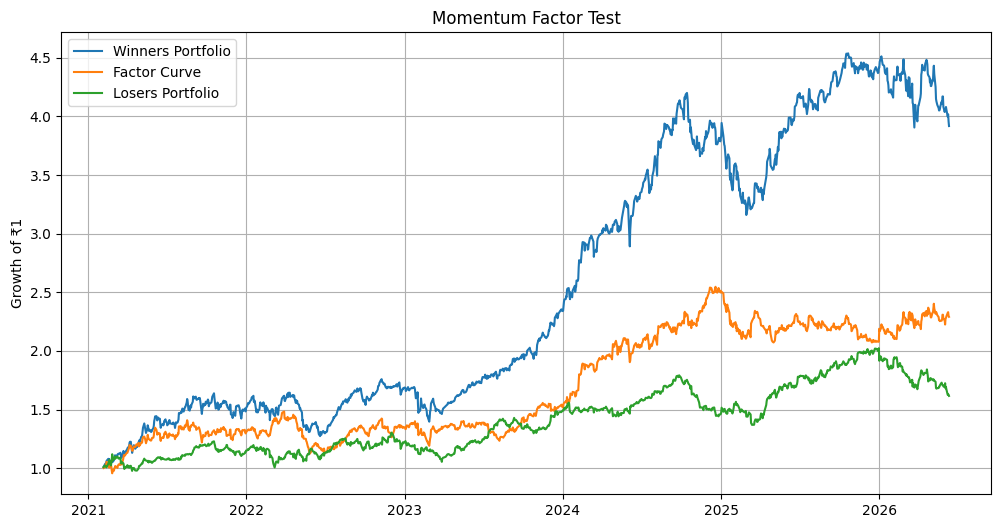

In [95]:
plt.figure(figsize=(12,6))

plt.plot(
    winner_curve,
    label="Winners Portfolio"
)

plt.plot(
    factor_curve,
    label="Factor Curve"
)

plt.plot(
    loser_curve,
    label="Losers Portfolio"
)

plt.title("Momentum Factor Test")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.grid(True)

plt.show()

In [96]:
print("="*60)
print("MOMENTUM PREMIUM")
print("="*60)

print(
    "Winner Return:",
    round((winner_curve.iloc[-1]-1)*100,2),
    "%"
)

print(
    "Loser Return:",
    round((loser_curve.iloc[-1]-1)*100,2),
    "%"
)



MOMENTUM PREMIUM
Winner Return: 291.74 %
Loser Return: 61.65 %
